In [ ]:
# torch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.transforms import transforms
import torch.optim as optim
# utils
import os
import numpy as np
from typing import Union
from pathlib import Path
from glob import glob
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
# visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix

In [3]:
# global variables
import os
from pathlib import Path
from glob import glob

device = "cuda" if torch.cuda.is_available() else "cpu"

# nombre de la carpeta donde está el dataset (relativa a la CWD del notebook)
dataset_name = "BrainMRI-Tumor-Classifier-BUENO"

def find_dataset_dir(name=dataset_name, start=None):
    start = Path(start or Path.cwd()).resolve()
    for p in [start] + list(start.parents):
        candidate = p / name
        if candidate.exists() and candidate.is_dir():
            return candidate
    return None

# localizar dataset (no cambiamos el CWD)
dataset_dir = find_dataset_dir()
if dataset_dir is None:
    # como fallback, aceptar ruta literal (por si ya es absoluta)
    candidate = Path(dataset_name)
    if candidate.exists() and candidate.is_dir():
        dataset_dir = candidate.resolve()

if dataset_dir is None:
    raise FileNotFoundError("No se encontró la carpeta 'BrainMRI-Tumor-Classifier-BUENO' desde CWD ni en los padres. CWD actual: " + str(Path.cwd()))

print("Dataset dir:", dataset_dir)

# rutas a subcarpetas
train_dir = str(dataset_dir / "Training")
test_dir = str(dataset_dir / "Testing")

image_size = (512, 512)
num_classes = 5

# función auxiliar para recoger imágenes (admite jpg, jpeg, png)
def gather_images(base_dir):
    patterns = ["*.jpg", "*.jpeg", "*.png"]
    paths = []
    for p in patterns:
        # se espera estructura base_dir/<class>/*.<ext>
        paths.extend(glob(os.path.join(base_dir, "*", p)))
    return sorted(paths)

train_paths = gather_images(train_dir)
test_paths = gather_images(test_dir)

# resumen rápido para depuración
print("Train samples:", len(train_paths))
print("Test samples:", len(test_paths))


Dataset dir: /mnt/c/Users/fabia/Desktop/Scripts/Python/PDI/BrainMRI-Tumor-Classifier-BUENO
Train samples: 5712
Test samples: 1311


In [5]:
# check device
device

'cuda'

In [6]:
# data augmentation
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [7]:
# custom dataset class
class dataset(Dataset):
    def __init__(self,paths,transform=None):
        self.paths = paths
        self.transform = transform
        self.labels = [self.get_label(path) for path in self.paths]
        self.labels_to_index = {label:index for index,label in enumerate(list(set(self.labels)))}
    
    def __getitem__(self,index):
        img_path = self.paths[index]
        img = Image.open(img_path).convert('RGB') 
        label = self.labels[index]
        label_index = self.labels_to_index[label]
        
        if self.transform:
            img = self.transform(img)
        
        return img, label_index,label
    
    
    def __len__(self):
        return len(self.paths)
    
    
    def get_label(self, path):
        return os.path.basename(os.path.dirname(path))

In [8]:
train_dataset = dataset(train_paths, transform=train_transform)
test_dataset = dataset(test_paths, transform=test_transform)

In [9]:
# --- División segura de test_dataset en val/test usando PyTorch ---
import torch

n = len(test_dataset)
print("len(test_dataset):", n)
if n == 0:
    raise ValueError("test_dataset tiene 0 muestras. Revisa 'test_paths' y las rutas (glob).")
if n < 2:
    raise ValueError(f"Imposible dividir: solo hay {n} muestra(s) en test_dataset.")

# dividir aproximadamente a la mitad (reproducible con semilla)
n_val = n // 2
n_test = n - n_val

generator = torch.Generator().manual_seed(ord("H"))
val_dataset, test_dataset = torch.utils.data.random_split(test_dataset, [n_val, n_test], generator=generator)

print(f"Split realizado: val={len(val_dataset)}, test={len(test_dataset)}")


len(test_dataset): 1311
Split realizado: val=655, test=656


In [10]:
print("len(val_dataset):", len(val_dataset))
print("len(test_dataset):", len(test_dataset))

len(val_dataset): 655
len(test_dataset): 656


In [11]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

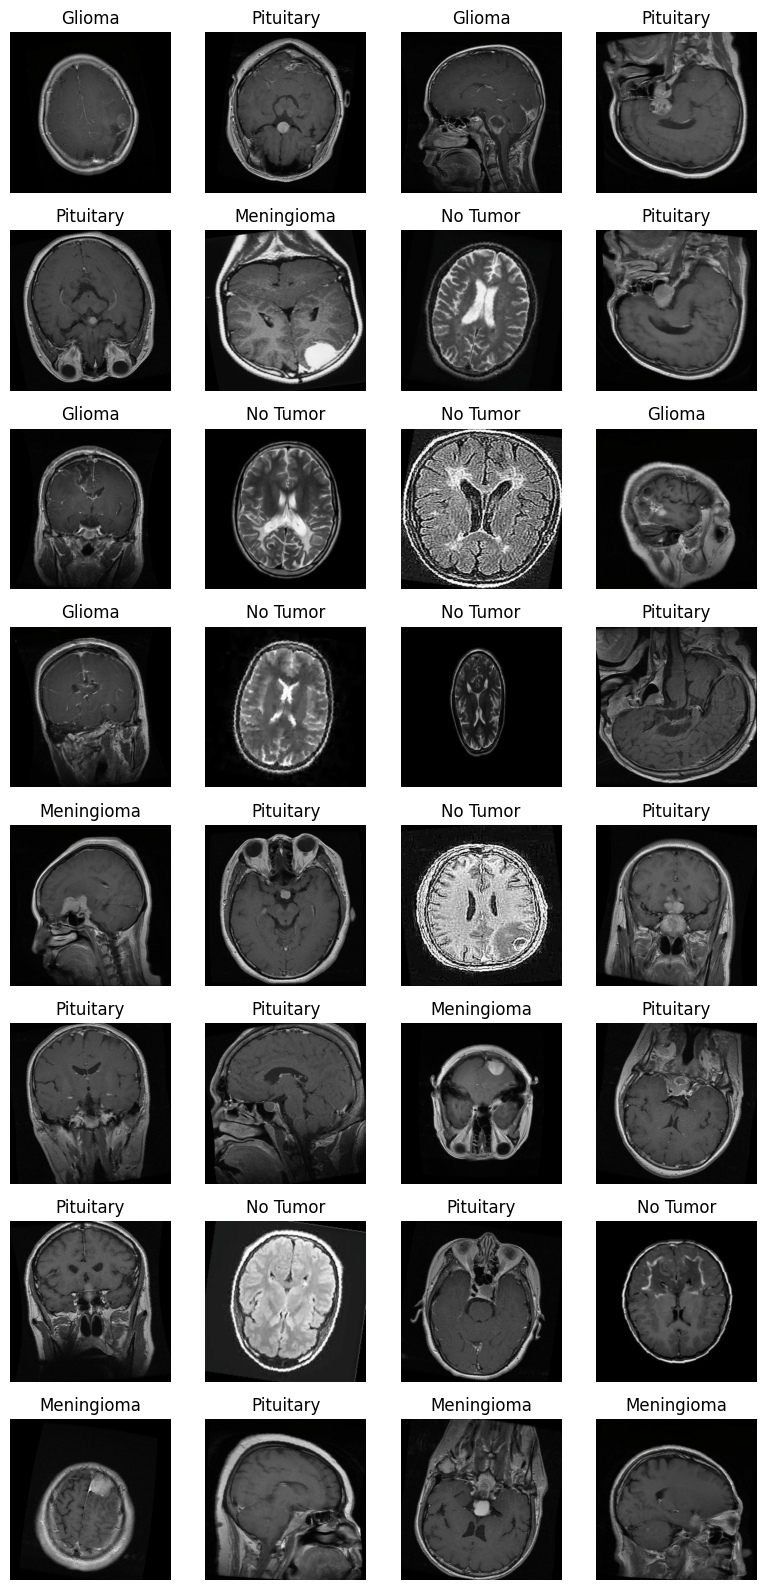

In [12]:
# display sample images with classes
train_iter = iter(train_loader)
images, labels_indices, labels = next(train_iter)

def imshow(input_images, labels_indices,labels):
    label_dict = {"notumor":"No Tumor", "glioma":"Glioma", "meningioma":"Meningioma","pituitary":"Pituitary"}
    input_images=input_images.numpy().transpose((0,2, 3, 1))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    input_images = std * input_images + mean
    input_images = np.clip(input_images, 0, 1)
    fig, axes = plt.subplots(8, 4, figsize=(8, 16))
    for i, ax in enumerate(axes.flat):
        ax.imshow(input_images[i])
        ax.axis('off')
        ax.set_title(label_dict[labels[i]], fontsize=12)
    plt.tight_layout()
    plt.show()


imshow(images, labels_indices,labels)

In [13]:
class ClassificationModel(nn.Module):
    def __init__(self, num_classes):
        super(ClassificationModel, self).__init__()

        # Convolutional blocks
        self.conv1 = nn.Conv2d(3, 32, kernel_size=4, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=1, padding=0)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=4, stride=1, padding=0)
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128, 128, kernel_size=4, stride=1, padding=0)
        self.bn4 = nn.BatchNorm2d(128)

        # Pooling layers
        self.pool = nn.MaxPool2d(kernel_size=3, stride=3)
        self.pool2 = nn.MaxPool2d(kernel_size=3, stride=2)

        # Use an adaptive pooling to guarantee a fixed-size feature map (6x6)
        # This makes the classifier independent of the input image spatial size.
        self.adaptive_pool = nn.AdaptiveAvgPool2d((6, 6))

        # Classifier
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(6 * 6 * 128, 512)
        self.fc2 = nn.Linear(512, num_classes)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.pool2(x)
        x = self.relu(self.bn4(self.conv4(x)))

        # Bring spatial dims to 6x6 regardless of input size
        x = self.adaptive_pool(x)

        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


In [14]:
model = ClassificationModel(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.0002)

In [15]:
def train_epoch():
    model.train()
    total_loss = 0.0 
    total_correct = 0
    total_predictions = 0
    
    for batch_number, (images, labels_indices, labels) in enumerate(train_loader):
        images, labels_indices = images.to(device), labels_indices.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels_indices)
        total_loss += loss.item()
        
        # Calculate accuracy
        _, predicted = torch.max(outputs, 1)
        total_predictions += labels_indices.size(0)
        total_correct += (predicted == labels_indices).sum().item()
        
        loss.backward()
        optimizer.step()
        
        if (batch_number and batch_number % 150 == 0):
            c_loss = total_loss / (batch_number + 1)
            accuracy = total_correct / total_predictions
            print(f"Batch {batch_number}/{len(train_loader)}, Loss: {c_loss:0.4f}, Accuracy: {accuracy * 100:.2f}%")
    
    avg_loss = total_loss / len(train_loader)
    avg_accuracy = total_correct / total_predictions
    
    return avg_loss, avg_accuracy


In [16]:
def eval_model():
    model.eval()
    total_loss = 0.0 
    total_correct = 0
    total_predictions = 0
    
    with torch.no_grad():
        for batch_number, (images, labels_indices, labels) in enumerate(val_loader):
            images, labels_indices = images.to(device), labels_indices.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels_indices)
            total_loss += loss.item()
            
            # Calculate accuracy
            _, predicted = torch.max(outputs, 1)
            total_predictions += labels_indices.size(0)
            total_correct += (predicted == labels_indices).sum().item()
            
    avg_loss = total_loss / len(val_loader)
    avg_accuracy = total_correct / total_predictions
    
    return avg_loss, avg_accuracy


In [17]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

In [ ]:
best_score = float("inf")
n_epochs = 30
tolerance = 0

for epoch in range(n_epochs):
    print(f"Epoch {epoch},   ", end="")
    avg_train_loss, train_accuracy = train_epoch()
    avg_eval_loss, eval_accuracy = eval_model()
    
    if avg_eval_loss < best_score:
        best_score = avg_eval_loss
        torch.save(model.state_dict(), f"model_{epoch+1}")
        tolerance = 0
    else:
        tolerance += 1
        if tolerance >= 8:
            break
            
    train_losses.append(avg_train_loss)
    val_losses.append(avg_eval_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(eval_accuracy)
    
    print(f"Train Loss: {avg_train_loss:.4f}, Train Accuracy: {train_accuracy * 100:.2f}%")
    print(f"Eval Loss: {avg_eval_loss:.4f}, Eval Accuracy: {eval_accuracy * 100:.2f}%")
    print("#" * 70)


Epoch 26,   Batch 150/179, Loss: 0.0798, Accuracy: 97.25%
Batch 150/179, Loss: 0.0798, Accuracy: 97.25%
Train Loss: 0.0809, Train Accuracy: 97.25%
Eval Loss: 0.1623, Eval Accuracy: 93.59%
######################################################################
Epoch 27,   Train Loss: 0.0809, Train Accuracy: 97.25%
Eval Loss: 0.1623, Eval Accuracy: 93.59%
######################################################################
Epoch 27,   Batch 150/179, Loss: 0.0805, Accuracy: 96.90%
Batch 150/179, Loss: 0.0805, Accuracy: 96.90%
Train Loss: 0.0789, Train Accuracy: 96.97%
Eval Loss: 0.1426, Eval Accuracy: 95.11%
######################################################################
Epoch 28,   Train Loss: 0.0789, Train Accuracy: 96.97%
Eval Loss: 0.1426, Eval Accuracy: 95.11%
######################################################################
Epoch 28,   Batch 150/179, Loss: 0.0637, Accuracy: 97.66%
Batch 150/179, Loss: 0.0637, Accuracy: 97.66%
Train Loss: 0.0633, Train Accuracy: 97.69%
E

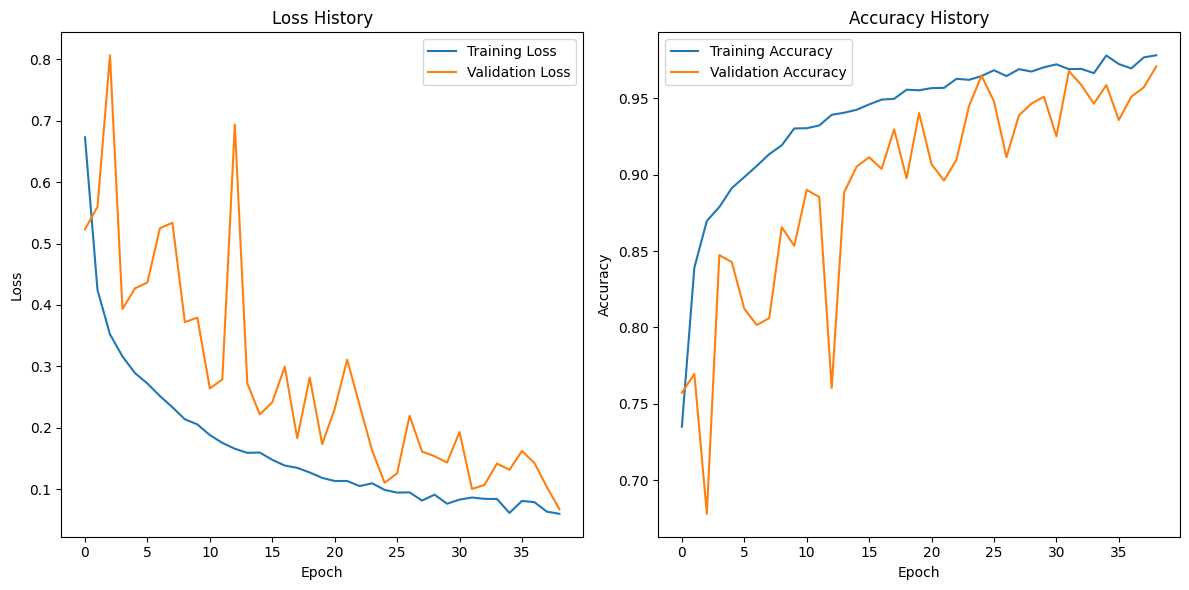

In [32]:
# Visualize training history
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss History')

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy History')

plt.tight_layout()
plt.show()

In [33]:
# Carga: buscar checkpoints numéricos en SegundoIntentoEntrenamiento y TercerIntento
from pathlib import Path
import re
from glob import glob

# carpetas a revisar (relativas a la raíz del proyecto dataset_dir si existe)
search_names = ["models"]

model_candidates = []
pattern = re.compile(r"model_(\d+)(?:\..*)?$")

for name in search_names:
    folder = Path(name)
    # si existe variable dataset_dir, preferimos buscar relativo a ella
    try:
        if 'dataset_dir' in globals() and dataset_dir is not None:
            folder = Path(dataset_dir) / name
    except Exception:
        pass

    if not folder.exists():
        # intenta también ruta relativa al notebook cwd
        folder = Path(name)
    if not folder.exists():
        # no existe esa carpeta, continuar
        continue

    # aceptar archivos con o sin extensión: model_*, model_*.pt, model_*/*
    for p in glob(str(folder / "model_*")):
        base = Path(p).name
        m = pattern.match(base)
        if m:
            model_candidates.append((int(m.group(1)), Path(p).resolve()))

# si no encontramos candidatos, intentar buscar en subcarpetas 'models' u otros lugares
if not model_candidates:
    # busca recursivamente en la carpeta del proyecto (limitado a profundidad 2)
    project_root = Path(dataset_dir) if ('dataset_dir' in globals() and dataset_dir is not None) else Path.cwd()
    for p in project_root.rglob('model_*'):
        base = Path(p).name
        m = pattern.match(base)
        if m:
            model_candidates.append((int(m.group(1)), p.resolve()))

if not model_candidates:
    raise FileNotFoundError(f"No se encontraron checkpoints tipo 'model_<número>' en {search_names} ni en el proyecto.")

# seleccionar el checkpoint con mayor número
best_num, best_model_path = max(model_candidates, key=lambda x: x[0])
print(f"Encontrados {len(model_candidates)} checkpoints. Seleccionando el mayor número: model_{best_num} -> {best_model_path}")

# best_model_path es un Path; si necesitas str:
best_model_path = str(best_model_path)
best_model_path

Encontrados 11 checkpoints. Seleccionando el mayor número: model_30 -> /mnt/c/Users/fabia/Desktop/Scripts/Python/PDI/BrainMRI-Tumor-Classifier-BUENO/models/model_30


'/mnt/c/Users/fabia/Desktop/Scripts/Python/PDI/BrainMRI-Tumor-Classifier-BUENO/models/model_30'

In [34]:
best_model = ClassificationModel(num_classes).to(device)

best_model.load_state_dict(torch.load(best_model_path, map_location=device))

<All keys matched successfully>

In [35]:
import torch
import numpy as np
from typing import Union

def predict(
    model: torch.nn.Module,
    sample_loader: torch.utils.data.DataLoader,
    device: Union[str, torch.device],
    return_numpy: bool = True,
    apply_softmax: bool = False,
) -> np.ndarray:
    """
    Inferencia segura:
    - maneja loaders que devuelven (X, y) o (X, y, labels)
    - evita errores si el loader está vacío
    - concatena eficientemente en torch y convierte a numpy al final (si return_numpy=True)
    - opcionalmente aplica softmax a las salidas
    """
    model.eval()
    device = torch.device(device)
    outputs_cpu = []

    softmax = torch.nn.functional.softmax if apply_softmax else (lambda x, dim: x)

    with torch.inference_mode():
        for batch in sample_loader:
            # aceptar (X, ...). Si el loader devuelve (X, y, labels) o (X, y) funciona.
            if isinstance(batch, (list, tuple)):
                X = batch[0]
            else:
                X = batch  # raro, pero por si el loader devolviera sólo X
            X = X.to(device)
            y_pred = model(X)  # tensor en device
            if apply_softmax:
                y_pred = softmax(y_pred, dim=1)
            # mover a CPU y almacenar como tensor para concatenar luego
            outputs_cpu.append(y_pred.detach().cpu())

    if not outputs_cpu:
        # Devuelve un array vacío con forma (0, 0) para evitar excepciones
        return np.empty((0, 0)) if return_numpy else torch.empty((0, 0))

    all_outputs = torch.cat(outputs_cpu, dim=0)  # (N, C)
    if return_numpy:
        return all_outputs.numpy()
    return all_outputs

In [36]:
best_model_props = predict(best_model, test_loader, device)

# Asegurarnos del tipo numpy
if isinstance(best_model_props, torch.Tensor):
    best_model_props = best_model_props.detach().cpu().numpy()

# Caso loader vacío
if best_model_props.size == 0:
    raise ValueError("predict devolvió 0 predicciones (loader vacío o fallo).")

# Si ya son vectores 1D (por ejemplo ya son clases), adaptamos
if best_model_props.ndim == 1:
    best_model_preds = best_model_props.astype(int)
elif best_model_props.ndim == 2:
    best_model_preds = np.argmax(best_model_props, axis=1)
else:
    raise ValueError(f"Formato inesperado de best_model_props: ndim={best_model_props.ndim}")

n_preds = best_model_preds.shape[0]
print("Número de predicciones:", n_preds)

Número de predicciones: 656


In [37]:
# etiquetas desde el dataset (si test_dataset soporta indexación)
true_labels = [item[1] for item in test_dataset]
assert len(true_labels) == n_preds, "Longitud de etiquetas y predicciones no coincide (revisa shuffle en DataLoader)."

In [38]:
gen_labels_test_set = [label[1] for label in test_dataset]
len(gen_labels_test_set)

656

In [39]:
print(f"Best Model Test Accuracy: {round(accuracy_score(gen_labels_test_set,best_model_preds)*100,2)}%")

Best Model Test Accuracy: 98.17%


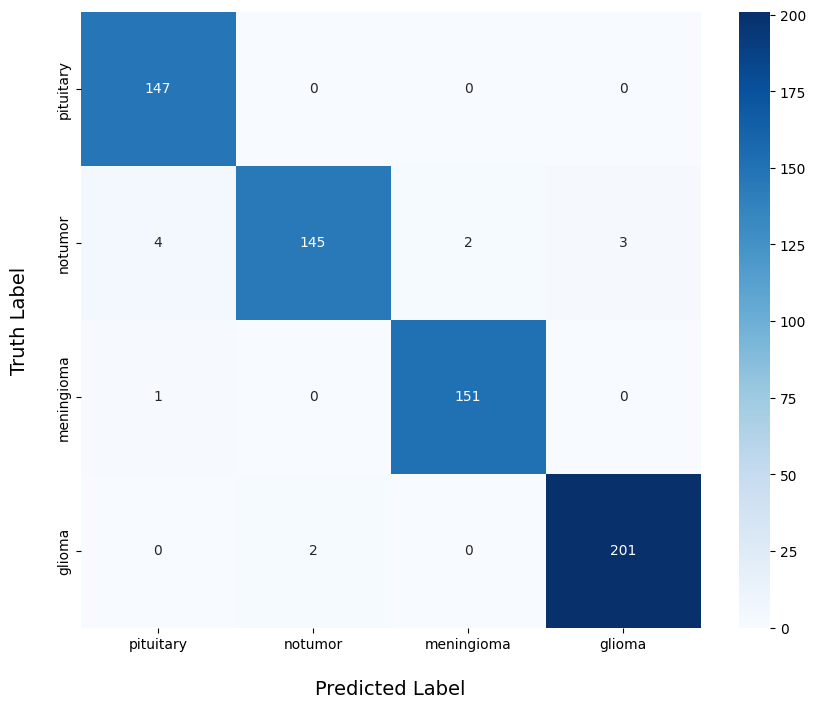

In [40]:
cm = confusion_matrix(gen_labels_test_set, best_model_preds)
labels = set([label[2] for label in test_dataset])
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label', labelpad=20, fontsize=14)
plt.ylabel('Truth Label', labelpad=20, fontsize=14)
plt.show()